# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Triptesh Biswas (s2857023), Arden Diakhate-Palme (s2818750)*

## Setup

*Install any packages here, define any functions if neeed, and load data*

In [1]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, recall_score, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin

import time

In [2]:
random_state = 100

### Data Loading

In [3]:
df_fs = pd.read_spss("ExtendedDataSources/fs.sav")
df_wm = pd.read_spss("ExtendedDataSources/wm.sav")
df_mn = pd.read_spss("ExtendedDataSources/mn.sav")
df_hh = pd.read_spss("ExtendedDataSources/hh.sav")

In [4]:
# match individual men / women biological father / mother to child
df_hh_fs = df_hh.merge(df_fs, on=['HH1', 'HH2'], how='inner', suffixes=('_hh', '_fs'))
dup_cols = [c for c in df_hh_fs.columns if c.endswith('_hh')]
df_hh_fs = df_hh_fs.drop(columns=dup_cols)
df_hh_fs.columns = [c.replace('_fs', '') for c in df_hh_fs.columns]

df_hh_fs_wm = df_hh_fs.merge(df_wm, on=['HH1', 'HH2', 'LN'], how='left', suffixes=('_hh_fs', '_wm'))
dup_cols = [c for c in df_hh_fs_wm.columns if c.endswith('_hh_fs')]
df_hh_fs_wm = df_hh_fs_wm.drop(columns=dup_cols)
df_hh_fs_wm.columns = [c.replace('_hh_fs', '') for c in df_hh_fs_wm.columns]

df = df_hh_fs_wm.merge(df_mn, on=['HH1', 'HH2', 'LN'], how='left',suffixes=('_hh_fs_wm', '_mn'))
dup_cols = [c for c in df_hh_fs_wm.columns if c.endswith('_hh_fs_wm')]
df = df.drop(columns=dup_cols)
df.columns = [c.replace('_hh_fs_wm', '') for c in df.columns]

In [5]:
df.shape

(17976, 1277)

# Introduction

*This section should include a brief introduction to the task and the data (assume this is a report you are delivering to a professional body (e.g. UNICEF)).*

*Briefly outline the approaches being used and the conclusions that you are able to draw.*

The mental health of the next generation is a social priority, and poor mental health impacts on low- and middle-income communities disproportionately. Using UNICEF’s Multiple Indicator Cluster Survey (MICS) from Malawi, Africa, which collects information on the child, parent, and household environment, this report seeks to shed light on the following:
1. How depression impacts intergenerational experiences & society
2. Potential social & health policies to address factors that may cause depression.

To this end, we developed two models to determine whether a child is depressed, and which factors (variables in the MICS dataset) are the biggest contributors to that child's poor mental health.

# Exploratory Data Analysis and Feature Engineering

*Include a detailed discussion of the data with a particular emphasis on the features of the data that are relevant for the subsequent modeling. Including visualizations of the data is strongly encouraged - all code and plots must also be described in the write up. Think carefully about whether each plot needs to be included in your final draft and the appropriate type of plot and summary for each variable type - your report should include figures but they should be as focused and impactful as possible.*

*You should also split your data into training and testing sets, ideally before you look to much into the features and relationships with the target.*

*Additionally, this section should also motivate and describe any preprocessing / feature engineering of the data. Pipelines should be used and feature engineering steps that are be performed as part of an sklearn pipeline can be mentioned here but should be implemented in the following section.*

*All code and figures should be accompanied by text that provides an overview / context to what is being done or presented.*

Before diving into the data it helps to take a step back and take a look at the way the survey was conducted, and to do preliminary research to determine which modules to focus on, this will help us isolate the right features, which will reduce the final model's size.

After performing some high-level research into child mental health, we determined that the following modules were most important, and further filtered the features in each module to include only the ones we found most pertinent to predicting depression. 

1. Questionnaire for Children age 5-17 years:`FCF` Child Functioning, `PR` Parental Involvement, `FCD` Child Discipline, `CL` Child Labor, `FL` Child Learning
  
2. Questionnaire for Individual Women age 15-49 years: `LS` Life Satisfaction, `DV` Attitutdes Towards Domestic Violence, `MA` Marriage / Union, `TA` Tobacco and Alcohol Use

3. Questionnaire for Individual Men age 15-49 years: `MLS` Life Satisfaction, `MDV` Attitutdes Towards Domestic Violence, `MVT` Victimization, `MTA` Tobacco and Alcohol Use

4. Household Questionnaire: `HC` Household Characteristics, `ST` Social Transfers, `WS` Water and Sanitation, `ED` Education (3+)

For each module we further filtered out the features which we deemed unrelated to child mental health after preliminary analysis / common sense. Other features are redundant (i.e. only `NaN` values in column or only `NaN` and a string as unqiue values), and are excluded as well.

In [6]:
modules = ['FCF', 'PR', 'FCD', 'CL', 'FL',
           'LS', 'DV', 'MA', 'TA',
           'MLS', 'MDV', 'MVT', 'MTA',
           'HC', 'ST', 'WS', 'ED']

In [7]:
excl_features = ['FL26', 'FL26A', 'FL26B', 'FL26C', 'FL26D', 'FL26E', 'FL26F', 'FL26X', 'FL3',
                 'TA8B', 'MAF11', 'MAF11', 'MAF12', 'MA7',
                 'MTA8NR', 'MVT18NR', 'MTA8B', 'MTA12A', 'MAF3', 'MVT13', 'MVT2', 'MVT5', 'MVT6',
                 'WS10NR', 'WS12', 'WS7'
                ]

redundant_features = ['MTA8B', 'TA12X', 'MTA12A', 'MVT7B', 'MTA8X', 'MTA8E', 'FLINTRO', 'FL13', 'TA8X', 'MVT7NR', 
                      'TA13', 'MTA12X', 'TA8D', 'TA9', 'TA12B', 'MTA8C', 'TA12C', 'FLB_INTRO', 'MTA12NR', 'MTA12B', 
                      'TA8NR', 'MTA13', 'MTA12C', 'MTA8A', 'FL16', 'MTA9', 'MVT18B', 'FL18', 'MTA8D', 'TA12NR', 'TA8A', 
                      'MVT11', 'TA8C', 'MVT3', 'TA12A', 'TA5']

excl_features = excl_features + redundant_features

In [8]:
def get_features(modules, excl_features):
    features = []
    for module in modules:
        features = features + [feature for feature in df.columns if feature.startswith(module) and feature not in excl_features]
    return features
features = get_features(modules, excl_features)

In [9]:
def get_cardinality(df, features, rare_threshold = 0.01):
    rows = []
    for feature in features:
        # we examine the normalized proportion of unique answers for all features in set
        val_ct = df[feature].value_counts(dropna=False, normalize=True).sort_values(ascending=False)
        rare_rows_mask = val_ct < rare_threshold
        rows.append({
            'feature':      feature,
            'n_unique':     df[feature].nunique(dropna=True),
            'n_null':       df[feature].isnull().sum(),
            'top_category': val_ct.index[0],
            'top_pct':      val_ct.iloc[0],
            'rare_pct':     rare_rows_mask.mean(),
        })

    ret = pd.DataFrame(rows)
    ret.set_index("feature", inplace=True)
    return ret

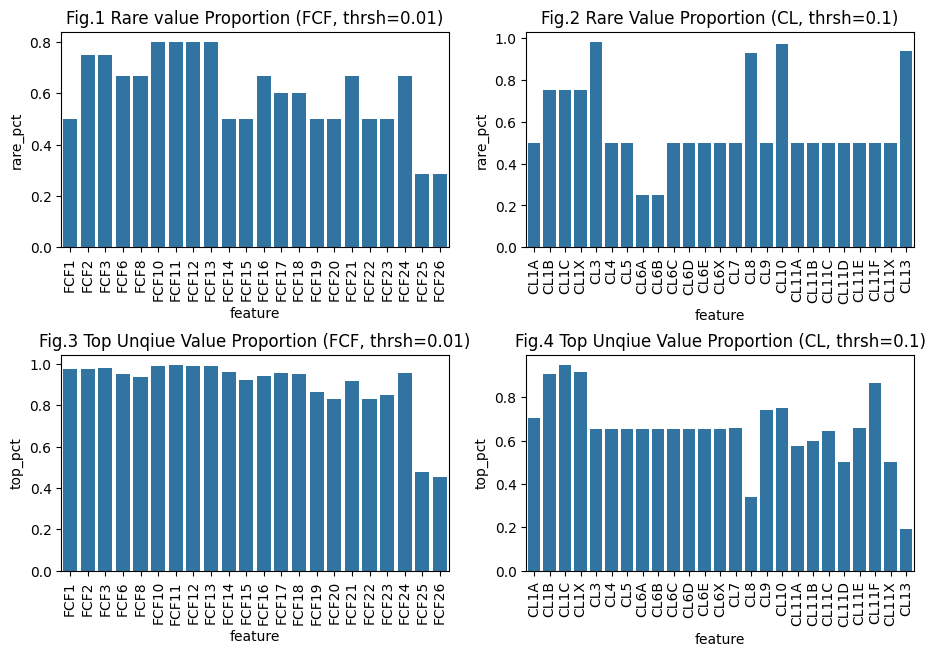

In [10]:
fig, ax = plt.subplots(2,2,figsize=(11,7))
df_card_fcf = get_cardinality(df, [feature for feature in df.columns if ('FCF' in feature)])
df_card_cl = get_cardinality(df, [feature for feature in df.columns if ('CL' in feature)], rare_threshold=0.1)

sns.barplot(df_card_fcf, x="feature", y="rare_pct", ax=ax[0,0])
ax[0,0].tick_params(axis='x', labelrotation=90)
ax[0,0].set_title("Fig.1 Rare value Proportion (FCF, thrsh=0.01)")

sns.barplot(df_card_cl, x="feature", y="rare_pct", ax=ax[0,1])
ax[0,1].tick_params(axis='x', labelrotation=90)
ax[0,1].set_title("Fig.2 Rare Value Proportion (CL, thrsh=0.1)")

sns.barplot(df_card_fcf, x="feature", y="top_pct", ax=ax[1,0])
ax[1,0].tick_params(axis='x', labelrotation=90)
ax[1,0].set_title("Fig.3 Top Unqiue Value Proportion (FCF, thrsh=0.01)")

sns.barplot(df_card_cl, x="feature", y="top_pct", ax=ax[1,1])
ax[1,1].tick_params(axis='x', labelrotation=90)
ax[1,1].set_title("Fig.4 Top Unqiue Value Proportion (CL, thrsh=0.1)")


plt.subplots_adjust(hspace=0.5)
plt.show()

In [11]:
df_card_fcf['top_category'].value_counts()

top_category
NO DIFFICULTY    13
NO                3
NEVER             2
Name: count, dtype: int64

The first row of the cardinality plots above show the percentage of per-feature rows (that take values in that feature's set of unique values) which occur less than $100\times$`rare_threshold`$\in\{0.01,0.1\}\%$ of the time. The second row show the percentage of each features rows in which the most-frequent unique value occurs. For features in the `FCF` module, the negative answer is most common (as seen in the output of `df_card_fcf['top_category'].value_counts()` above). 

Fig.3 shows that $40\%$ of the dataset consists of happy children (i.e. children never feeling depressed), and that most children are well functioning since `FCF_X` features usually correspond to questions concerning negative feelings (e.g. anxiety, difficulties, etc..) and the predominant answers are most of the time `NEVER` or `NO DIFFICULTY`. 

#### Preprocessing

Most of these columns are categorical, and even the "numerical" features have their constituents represented as strings, often with an additional `NO RESPONSE` or `DK` answer, necessitating the use of sophicsticated pipelines. See class `PreProcessor` section 6 in the code for more details.

In [12]:
num_features = ['CL13', 'CL8', 'CL3', 'CL10', 'FL20A', 'FL20B', 'FLB20A', 'FLB20B', 'FL2H', 'FL2M',
                'LS2', 'MA2', 'MA4', 'MA11', 'MA8Y', 'TA2', 'TA4', 'TA15', 'TA17',
                'MLS2', 'MTA2', 'MTA4', 'MTA15', 'MTA17',
                'HC18D', 'HC18E', 'HC18G', 'HC18H', 'ST4N$1', 'ST4N$2', 'ST4N$3', 'ST4N$4', 'ST4N$5', 'WS4', 'WS5', 'WS6', 'HC3', 'HC16A', 'HC18A', 'HC18B', 'HC18C', 'HC18F']

After identifying numerical features, we identify a small subset of features whose corresponding questionare questions have binary responses (or binary with a third "don't know" or "no response/attempt" answer). These features will be encoded with one-hot-encoding.
Although one-hot encoding results in more features and higher dimensionality of the dataset $X\in\mathbb{R}^{n\times D}$, we will later determine which modules or features are redundant and apply PCA to reduce the number of features before fitting our models.

In [13]:
one_hot_features = ["MA1", "FL1", "HC8", "MVT8", "MVT19", "MA5", "MA1",]

Finally, we use ordinal enoders where there is a sense of order to the response (e.g. levels of happiness, distance, or time duration) and one-hot encoding otherwise. We only consider certain columns for one-hot encoding (columns not specified are dropped so the final set of features is a subset of all features in the modules in the `modules` list above).

Additionally, we consider `NaN` responses to be indicative of no response i.e. this was an inputing error on the survey's administrator's part, who left the field blank when the participant failed to respond to the question.

In [14]:
class RepeatedOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, order):
        '''
        This class extends TransformerMixin (defines fit_transform) and BaseEstimator 
        It assumes that all columns share the same ordered categories, and allows including these kind of ordinal encoders in later pipelines
        '''
        self.order = order

    def fit(self, X, y=None):
        self.enc = OrdinalEncoder(
            # replicates ordinal categories so that each input row has same ordinal encoding
            categories=[self.order] * X.shape[1], 
            handle_unknown='use_encoded_value',
            unknown_value=np.nan
        )
        self.enc.fit(X)
        return self

    def transform(self, X):
        return self.enc.transform(X)

    # required for retrieving feature names downstream
    def get_feature_names_out(self, input_features=None):
        return input_features

In [15]:
class PreProcessor(ColumnTransformer):
    def __init__(self, df, features, one_hot_features=[], num_features=[]):
        self.num_features = num_features
        self.one_hot_features = one_hot_features
        self.ord_features = [] # filled later
        self.features = features # subset of df.columns
        self.df = df
        
        self.transformers= dict()
        self.transformers['ord'] = []
        self.transformers['num'] = []
        self.transformers['one_hot'] = []
        
        self.encode_ord()
        self.encode_num()
        self.encode_one_hot()
        
        transformers = self.transformers['one_hot'] + self.transformers['ord'] + self.transformers['num']
        super().__init__(transformers=transformers, verbose_feature_names_out=True,remainder='drop')
        
    def encode_ord(self):
        ordinal_answer_orders = dict()
        ordinal_answer_orders['yn'] = ['NO', 'YES', 'NO RESPONSE']
        ordinal_answer_orders['yndk'] = ['NO', 'YES', 'DK', 'NO RESPONSE']
        ordinal_answer_orders['cinr'] = ['CORRECT', 'INCORRECT', 'NOT REACHED']
        ordinal_answer_orders['cina'] = ['CORRECT', 'INCORRECT', 'NO ATTEMPT']
        ordinal_answer_orders['do'] = ['NO DIFFICULTY', 'SOME DIFFICULTY', 'A LOT OF DIFFICULTY']
        ordinal_answer_orders['freq'] = ['NEVER', 'A FEW TIMES A YEAR', 'MONTHLY', 'WEEKLY', 'DAILY', 'NO RESPONSE']
        ordinal_answer_orders['freq2'] = ['ONLY ONCE', 'MORE THAN ONCE']
        ordinal_answer_orders['freq3'] = ['ONE TIME', 'TWO TIMES', 'THREE OR MORE TIMES']
        ordinal_answer_orders['time_ago'] = ['MONTHS AGO', 'YEARS AGO']
        ordinal_answer_orders['time_ago2'] = ['YES, DURING THE LAST 12 MONTHS', 'NO, MORE THAN 12 MONTHS AGO']
        ordinal_answer_orders['people'] = ['ONE PERSON', 'THREE OR MORE PEOPLE', 'TWO PEOPLE'] 
        ordinal_answer_orders['grade'] = ['CLASS/YEAR/GRADE 1', 'CLASS/YEAR/GRADE 2', 'CLASS/GRADE 3', 'CLASS/YEAR/GRADE 4',
                                          'CLASS/GRADE 5', 'CLASS/GRADE 6', 'CLASS/YEAR/GRADE 7', 'CLASS/YEAR/GRADE 8']
        ordinal_answer_orders['edu'] = ['ECE', 'LOWER SECONDARY', 'PRIMARY', 'UPPER SECONDARY', 'VOCATION TRAINING', 'HIGHER']
        
        ordinal_answer_types = ['do', 'yn', 'yndk', 'cinr', 'cina', 'freq', 'freq2', 'freq3',
                        'time_ago', 'time_ago2', 
                        'grade', 'edu', 'people']
        ord_features_table = {key:[] for key in ordinal_answer_types}
        
        nan_resp = ['no response', 'dk', 'no attempt', 'not reached', 'no difficulty']

        for feature in set(self.features).difference(set(self.num_features)).difference(set(self.one_hot_features)):
            uresp = self.df[feature].unique()
        
            # 1. Replace nan-equivalent responses
            for resp in nan_resp:
                mask = np.array([resp in str(s).strip().lower() for s in uresp])
                if any(mask):
                    self.df.loc[self.df[feature].isnull(),feature] = str(uresp[mask][0])
        
            # 2. Replace missing values in binary columns with NO
            if(set(self.df[feature].unique()) == {'NO', 'YES', np.nan}):
                self.df.loc[self.df[feature].isnull(),feature] = 'NO'
                self.one_hot_features.append(feature)
                continue # these will be passed to one-hot encoder
                
            # 3. Features with yes/no or correct/incorrect responses should be one-hot encoded
            if((any('yes' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('no' in str(s).strip().lower() for s in self.df[feature].unique())) or \
               (any('correct' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('incorrect' in str(s).strip().lower() for s in self.df[feature].unique()))):
                one_hot_features.append(feature)
                continue # these will be passed to one-hot encoder
            
            # 4. Group the ordinal columns
            if any('no difficulty' in str(s).strip().lower() for s in self.df[feature].unique()) or \
               any('some difficulty' in str(s).strip().lower() for s in self.df[feature].unique()) or \
               any('a lot of difficulty' in str(s).strip().lower() for s in self.df[feature].unique()):
                ord_features_table['do'].append(feature)
        
            if (any('weekly' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('daily' in str(s).strip().lower() for s in self.df[feature].unique())):
                    ord_features_table['freq'].append(feature)
        
            if any('one time' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['freq2'].append(feature)
                
            if any('only once' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['freq3'].append(feature)
                
            if (any('years ago' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('months ago' in str(s).strip().lower() for s in self.df[feature].unique())):
                    ord_features_table['time_ago'].append(feature)
        
            if any('class/year/grade' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['grade'].append(feature)
                
            if any('lower secondary' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['edu'].append(feature)
                
            if any('one person' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['people'].append(feature)
                
        def replace_dk(X):
            X = pd.DataFrame(X).copy()
            X = X.astype(object)
            dk_variants = [v for v in X.stack().unique() if str(v).startswith('DK')]
            return X.replace(dk_variants, np.nan)
        
        def get_pipeline(answer_type):
            return Pipeline([
                ('replace_dk', FunctionTransformer(replace_dk, feature_names_out='one-to-one')),
                ('ordinal', RepeatedOrdinalEncoder(order=ordinal_answer_orders[answer_type])),
                ('impute', SimpleImputer(strategy='mean')),
            ])
        
        # 5. create column-wise transformers with an inputing strategy for ordinal encodings too
        for answer_type in ['edu', 'grade', 'time_ago']:
            self.transformers['ord'].append((answer_type, get_pipeline(answer_type), ord_features_table[answer_type]))

        for feature in ord_features_table['do']:
            if(len(self.df[feature].unique()) > 2):
                # this generalizes the last encoding since many different questions all have variants
                # of a negative response that starts of the form "Cannot __"
                cannot_labels = [v for v in self.df[feature].unique() if str(v).startswith('CANNOT')]
                order = ordinal_answer_orders['do'] + cannot_labels + ['NO RESPONSE']
                self.transformers['ord'].append((feature, OrdinalEncoder(categories=[order]), [feature]))
            else:
                self.one_hot_features.append(feature) # these are essentially binary features now

        for t in [ans for ans in ordinal_answer_types if ans not in ['do','edu','grade','time_ago']]:
                self.transformers['ord'].append((t, OrdinalEncoder(
                    categories=[ordinal_answer_orders[t]]*len(ord_features_table[t])),ord_features_table[t]))
            
    def encode_num(self):
        # 6. encode string responses in numerical features
        def parse_num_value(v):
            if isinstance(v, str):
                if v.startswith('NEVER') or v.startswith('MEMBERS'):
                    return 0.0
                if v in ['NO RESPONSE', 'DK']:
                    return np.nan
                v = v.replace('+','')
            return float(v)
        
        def clean_num_col(X):
            X = X.copy()
            for col in X.columns:
                X[col] = X[col].apply(parse_num_value)
            return X
        
        self.transformers['num'].append(('num', Pipeline([
            ('clean', FunctionTransformer(clean_num_col, feature_names_out='one-to-one')),
            ('impute', SimpleImputer(strategy='mean')), # mean inputer 
        ]), self.num_features))
        
    def encode_one_hot(self):
        self.transformers['one_hot'].append(('one_hot', OneHotEncoder(drop='first', min_frequency=0.2), self.one_hot_features))


The `PreProcessor` class above extends `ColumnTransformer` and allows for custom ordinal encoding and numerical encoding. 

**Part 1** addresses the `NaN` values. These null entries are replaced by the appropriate question response in `nan_resp` based on the unique values for that feature.

**Part 4** appears daunting but this is just creating a mapping between features and ordinal encoding types so that the right transformers can be created later; it does so by checking whether unique responses include certain keywords and routes those features to an ordinal encoding type.

**Part 5** in class member function `encode_ord()` requires more discussion. Several features could be ordinal encoded this entails questionaire responses to for instance grade-level or education level. For these answer types, we assume that a no-response would be an average response (so we take the average encoding of the level to be that participant's answer). 

This class allows for modular reconfiguration of the preprocessor pipeline, so that we can easily add and remove features to the encodings which we deem necessary and/or significant

In [16]:
pre_processor = PreProcessor(df,features, num_features=num_features, one_hot_features=one_hot_features)

#### Exploratory Data Analysis

In [17]:
%%capture
df_clean = pd.DataFrame(pre_processor.fit_transform(df[features]), columns=pre_processor.get_feature_names_out())

In [18]:
mask = df_clean['freq__FCF26'] == 0
df_clean.loc[mask,'freq__FCF26'] = 0
df_clean.loc[~mask,'freq__FCF26'] = 1

y = df_clean['freq__FCF26']
X = df_clean.drop(columns=['freq__FCF26'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

df_train = X_train
df_train['freq__FCF26'] = y

In [19]:
def get_corr_hist(df_train, modules):
    target_corr = dict()
    corr_rows = []
    for module in modules:
        target_features = [feature for feature in df_train.columns if (module in feature)] 
        if(module != 'FCF'):
            target_features.append('freq__FCF26')

        # calculate per-feature absolute correlation with encoded target feature FCF26
        target_corr[module] = np.abs(df_train[target_features].corr())['freq__FCF26']
        target_corr[module].drop(labels=['freq__FCF26'], inplace=True)
        corr_rows.append({
            'module':module,
            'mean':target_corr[module].mean(),
            'max':target_corr[module].max(),
        })
        
    df_corr = pd.DataFrame(corr_rows)
    df_corr.set_index('module', inplace=True)
    return df_corr.copy()
    
df_corr = get_corr_hist(df_train, modules)

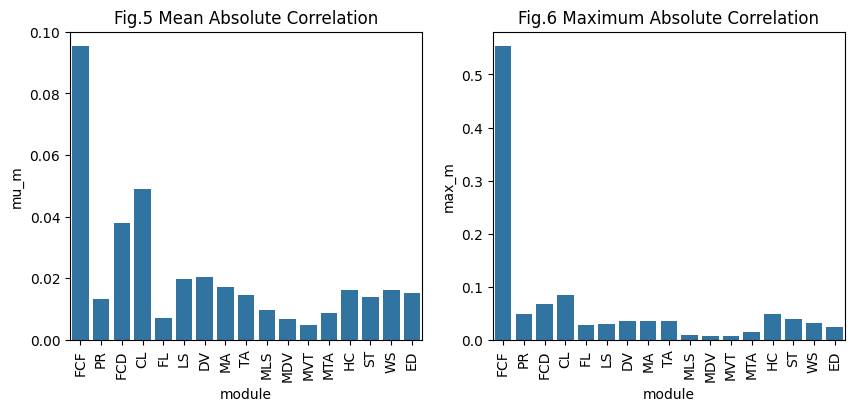

In [20]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
sns.barplot(data=df_corr, x=df_corr.index, y="mean", ax=ax[0])
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_ylabel('mu_m')
ax[0].set_title('Fig.5 Mean Absolute Correlation')

sns.barplot(data=df_corr, x=df_corr.index, y="max", ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_ylabel('max_m')
ax[1].set_title('Fig.6 Maximum Absolute Correlation')

plt.show()

Let r.v. $Y$ represent the child depression target variable `FCF26` and let $X_{f}$ be the random variable corresponding to feature $f\in F$ where $F$ is the set of considered features (`features` list in code above). Let $F_m\subset F$ be the set of features in module $m\in M$ where $M$ is the set set of all modules (`modules` list in code above).

$$
\mu_m=\frac{1}{|F_m|}\sum_{f\in F_m} |\text{Corr}(X_f,Y)|\quad\text{and}\quad \text{max}_m=\text{max}_{f\in F_m} |\text{Corr}(X_f,Y)|\quad \text{for}\; m\in M
$$

Figures 5 and 6 show that modules `FCF`, `PR`, `CL`, `FCD`, `HC` have the highest maximum correlation and  with child depression, so we could focus our attention on just these columns. This corroborates our initial guesses that these sets of features were the most influencial in classifying child depression.

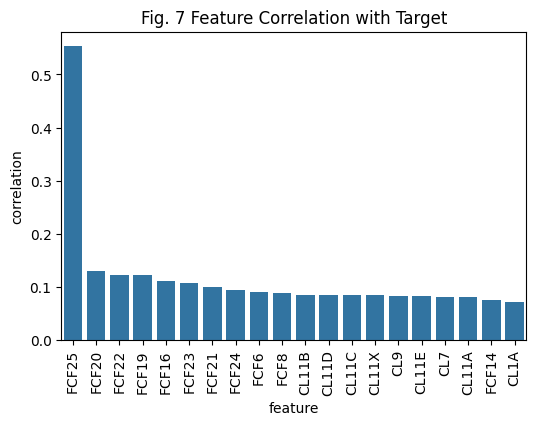

In [21]:
fig,ax = plt.subplots(1,1,figsize=(6,4))
corr_vec = df_train.corr()['freq__FCF26'].sort_values(ascending=False)
imp_feat = []
for f in list(corr_vec.index[1:21]):
    imp_feat.append({'feature':f.split('__')[1].split("_")[0], 'correlation': corr_vec[f]})
sns.barplot(pd.DataFrame(imp_feat), x="feature", y="correlation", ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_title("Fig. 7 Feature Correlation with Target")
plt.show()

The fact that `FCF25` shows the highest correlation with child depression is not surprising since the corresponding survey question is:
"I would like to know how often (name) seems very anxious, nervous or worried." with answers: `[Daily, Weekly, Monthly, A few times a year, Never]`. The next features showing the highest correlation with the target are all from the child labor `CL` or child functioning `FCF` modules, which suggests that further feature elimination may be possible.

# Model Fitting and Tuning

*In this section you should detail and motivate your choice of model and describe the process used to refine, tune, and fit that model. You are encouraged to explore different models but you should NOT include a detailed narrative or code of all of these attempts. At most this section should very briefly mention the methods explored and why they were rejected - most of your effort should go into describing the final model you are using and your process for tuning and validating it.*

*This section should include the full implementation of your final model, including all necessary validation. As with figures, any included code must also be addressed in the text of the document.*

*You should also include a baseline model of your choice and provide a comparison of your model with the baseline model on the test data. You should briefly describe the baseline model considered.*

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Test Accuracy: 0.8476084538375973


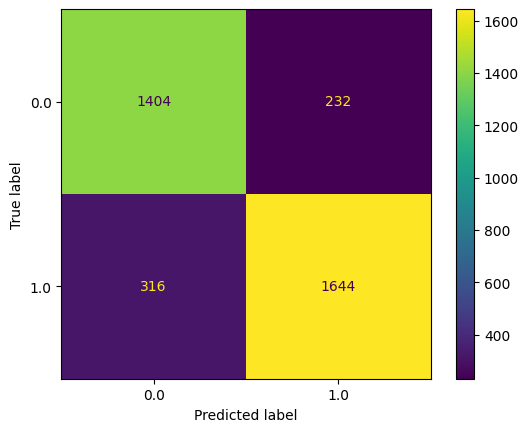

In [24]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)

y_test_pred = pipeline.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.show()

In [25]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      1636
         1.0       0.88      0.84      0.86      1960

    accuracy                           0.85      3596
   macro avg       0.85      0.85      0.85      3596
weighted avg       0.85      0.85      0.85      3596



In [26]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=0.95,
                   random_state=42)),
    ("svm",    SVC(kernel="rbf",
                   C=1,
                   gamma="scale",
                   random_state=42)),
])

In [27]:
start = time.time()
pipe.fit(X_train, y_train)
end = time.time()

print(f"Training time: {end - start:.4f} seconds")

Training time: 8.8039 seconds


In [28]:
start = time.time()
y_pred = pipe.predict(X_test)
end = time.time()

print(f"Testing time: {end - start:.4f} seconds")

Testing time: 2.7994 seconds


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.84      0.82      1636
         1.0       0.86      0.82      0.84      1960

    accuracy                           0.83      3596
   macro avg       0.83      0.83      0.83      3596
weighted avg       0.83      0.83      0.83      3596



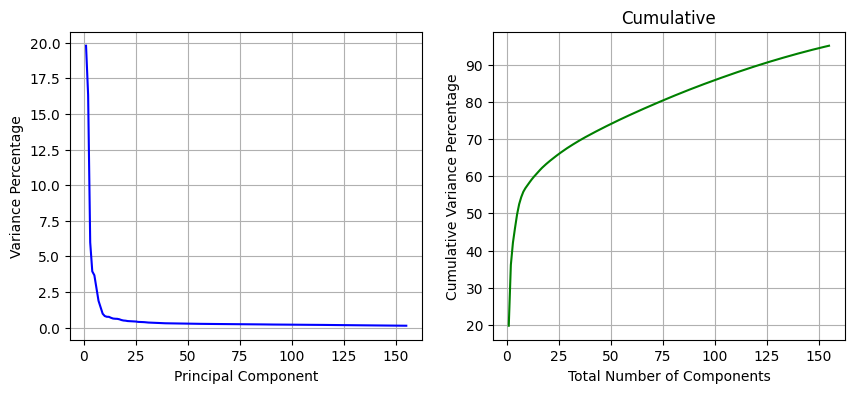

Optimal number of components:  155
Total percentage of variance explained by optimal components:  95.06057800099252


In [30]:
proportion_of_variance = pipe["pca"].explained_variance_ratio_
proportion_of_variance_cum = np.cumsum(proportion_of_variance)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(proportion_of_variance) + 1), proportion_of_variance * 100, 'b-')
plt.xlabel('Principal Component')
plt.ylabel('Variance Percentage')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(proportion_of_variance_cum) + 1), proportion_of_variance_cum * 100, 'g-')
plt.xlabel('Total Number of Components')
plt.ylabel('Cumulative Variance Percentage')
plt.title('Cumulative')
plt.grid(True)

plt.show()

optimal_components = np.argmax(proportion_of_variance_cum >= 0.95) + 1
total_variance_explained = proportion_of_variance_cum[optimal_components-1] * 100

print("Optimal number of components: ", optimal_components)
print("Total percentage of variance explained by optimal components: ", total_variance_explained)

Test Accuracy: 0.828420467185762


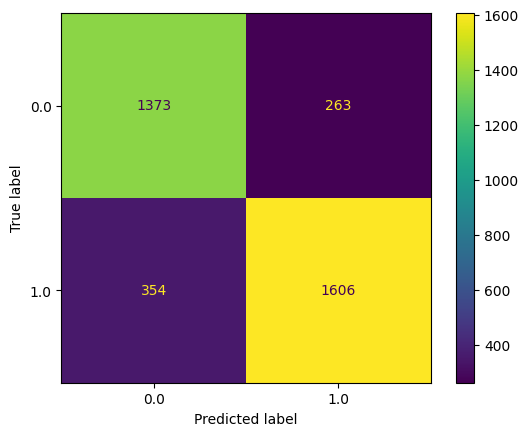

In [31]:
y_test_pred = pipe.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
plt.show()

# Interpretation, Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a government official, who understands the issues associated with mental health but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of depression, which may be useful for the government officials and health care workers to improve their understanding of the condition, and potentially assit in the development of effective social and health policies and interventions.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explanations / justifications.*

# Generative AI statement

*Include a statement on how generative AI was used in the project and report.*

# References

*Include references if any*

In [34]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project_eda.ipynb

[NbConvertApp] Converting notebook project_eda.ipynb to pdf
[NbConvertApp] Support files will be in project_eda_files/
[NbConvertApp] Making directory ./project_eda_files
[NbConvertApp] Writing 115786 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 321310 bytes to project_eda.pdf
